In [1]:
import sys
import pandas as pd
import random
import copy
from queue import PriorityQueue 
from functools import partial
import math
from collections import defaultdict
import numpy as np
import heapq
import networkx as nx
from collections import Counter
import time
from tqdm import tqdm
import itertools
import matplotlib.pyplot as plt
import matplotlib.pylab as pl
import matplotlib.colors as mcolors
from IPython.display import display, clear_output
from scipy.sparse import csr_matrix
from scipy.spatial import distance
from scipy.spatial.distance import pdist, cdist
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from functools import reduce, partial
from scipy.stats import wasserstein_distance
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from pynndescent import NNDescent
from pynndescent import distances as PyNNDD
import torch
import torch.nn as nn
import torch.optim as optim
import numba
import pykeops
from pykeops.torch import LazyTensor
import torch.distributions as dist

%matplotlib inline
torch.set_printoptions(precision=3)

/home/bdezoysa/.conda/envs/py310/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/bdezoysa/.conda/envs/py310/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/home/bdezoysa/.conda/envs/py310/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
def keops_knn_geo(source_dataset: torch.Tensor, target_dataset: torch.Tensor, k: int = 10, query_chunk_size: int = 100_000, device: str = 'cuda'):
    N_q, D = source_dataset.shape
    N_k, D_target = target_dataset.shape
    
    # Sanity check to ensure both datasets have the same number of features
    assert D == D_target, f"Feature dimensions must match! Source has {D}, Target has {D_target}."
    
    # 1. Pre-allocate output on CPU to save VRAM
    final_indices = torch.zeros((N_q, k), dtype=torch.long)
    final_distances = torch.full((N_q, k), float('inf'), dtype=torch.float32)

    # 2. Move the ENTIRE target corpus to GPU
    target_gpu = target_dataset.to(device)
    
    # 3. Create the symbolic LazyTensor for the corpus (The "Y" matrix)
    # Shape becomes (1, N_k, D) for broadcasting
    y_j = LazyTensor(target_gpu.view(1, N_k, D))

    # 4. Loop through queries (source) in chunks
    for i in range(0, N_q, query_chunk_size):
        end_i = min(i + query_chunk_size, N_q)
        
        # Extract the query chunk and move it to the GPU dynamically
        # This keeps our VRAM footprint strictly to Target + (1 * query_chunk_size)
        q_chunk = source_dataset[i:end_i].to(device)
        
        # Create symbolic LazyTensor for the queries (The "X" matrix)
        # Shape becomes (Q, 1, D) for broadcasting
        x_i = LazyTensor(q_chunk.view(-1, 1, D))
        
        # 5. Symbolic Chebyshev Distance calculation
        dists_ij = (x_i - y_j).abs().sum(dim=-1)
        
        # 6. Execute the CUDA Kernel
        # Kmin_argKmin performs the reduction over the 'j' dimension (dim=1) to find top-k
        dists, idx = dists_ij.Kmin_argKmin(K=k, dim=1)
        
        # Save chunk results to CPU
        final_distances[i:end_i] = dists
        final_indices[i:end_i] = idx
        
        print(f"Processed queries {i} to {end_i} out of {N_q}")

    return final_distances, final_indices

def keops_knn_pal(density: torch.Tensor, position: torch.Tensor, k: int = 10, query_chunk_size: int = 100_000, device: str = 'cuda'):
    N, dD = density.shape
    N, pD = position.shape
    
    # 1. Pre-allocate output on CPU to save VRAM
    final_indices = torch.zeros((N, k), dtype=torch.long)
    final_distances = torch.full((N, k), float('inf'), dtype=torch.float32)

    # 2. Move the ENTIRE dataset to GPU (approx 5GB for 10M x 128d in fp32)
    density_gpu = density.to(device)
    position_gpu = position.to(device)
    
    # 3. Create the symbolic LazyTensor for the corpus (The "Y" matrix)
    # Shape becomes (1, N, D) for broadcasting
    y_d_j = LazyTensor(density_gpu.view(1, N, dD))
    y_p_j = LazyTensor(position_gpu.view(1, N, pD))

    # 4. Loop through queries in chunks
    for i in range(0, N, query_chunk_size):
        end_i = min(i + query_chunk_size, N)
        
        # Extract the query chunk directly from the GPU dataset
        q_chunk_d = density_gpu[i:end_i]
        q_chunk_p = position_gpu[i:end_i]
        
        # Create symbolic LazyTensor for the queries (The "X" matrix)
        # Shape becomes (Q, 1, D) for broadcasting
        x_d_i = LazyTensor(q_chunk_d.view(-1, 1, dD))
        x_p_i = LazyTensor(q_chunk_p.view(-1, 1, pD))
        
        pos_dist = (x_p_i - y_p_j).abs().sum(dim=-1) / pD
        tar_dist = (x_d_i - y_d_j).abs().sum(dim=-1) / dD

        dists_ij = (1.0 - pos_dist) + tar_dist
        
        # 6. Execute the CUDA Kernel
        # Kmin_argKmin performs the reduction over the 'j' dimension (dim=1) to find top-k
        dists, idx = dists_ij.Kmin_argKmin(K=k, dim=1)
        
        # Save chunk results to CPU
        final_distances[i:end_i] = dists.cpu()
        final_indices[i:end_i] = idx.cpu()
        
        print(f"Processed queries {i} to {end_i} out of {N}")

    return final_distances, final_indices

def keops_knn_foe(density: torch.Tensor, position: torch.Tensor, k: int = 10, query_chunk_size: int = 100_000, device: str = 'cuda'):
    N, dD = density.shape
    N, pD = position.shape
    
    # 1. Pre-allocate output on CPU to save VRAM
    final_indices = torch.zeros((N, k), dtype=torch.long)
    final_distances = torch.full((N, k), float('inf'), dtype=torch.float32)

    # 2. Move the ENTIRE dataset to GPU (approx 5GB for 10M x 128d in fp32)
    density_gpu = density.to(device)
    position_gpu = position.to(device)
    
    # 3. Create the symbolic LazyTensor for the corpus (The "Y" matrix)
    # Shape becomes (1, N, D) for broadcasting
    y_d_j = LazyTensor(density_gpu.view(1, N, dD))
    y_p_j = LazyTensor(position_gpu.view(1, N, pD))

    # 4. Loop through queries in chunks
    for i in range(0, N, query_chunk_size):
        end_i = min(i + query_chunk_size, N)
        
        # Extract the query chunk directly from the GPU dataset
        q_chunk_d = density_gpu[i:end_i]
        q_chunk_p = position_gpu[i:end_i]
        
        # Create symbolic LazyTensor for the queries (The "X" matrix)
        # Shape becomes (Q, 1, D) for broadcasting
        x_d_i = LazyTensor(q_chunk_d.view(-1, 1, dD))
        x_p_i = LazyTensor(q_chunk_p.view(-1, 1, pD))
        
        pos_dist = (x_p_i - y_p_j).abs().sum(dim=-1) / pD
        tar_dist = (x_d_i - y_d_j).abs().sum(dim=-1) / dD

        dists_ij = pos_dist + (1.0 - tar_dist)
        
        # 6. Execute the CUDA Kernel
        # Kmin_argKmin performs the reduction over the 'j' dimension (dim=1) to find top-k
        dists, idx = dists_ij.Kmin_argKmin(K=k, dim=1)
        
        # Save chunk results to CPU
        final_distances[i:end_i] = dists.cpu()
        final_indices[i:end_i] = idx.cpu()
        
        print(f"Processed queries {i} to {end_i} out of {N}")

    return final_distances, final_indices

In [3]:
# Create a DataFrame with num_cols columns of uniform random samples
num_cols = 3
num_rows = 100000
num_bins = 64 #(num_bins)
df = pd.DataFrame(np.random.rand(num_rows, num_cols), columns=[f'x{i}' for i in range(num_cols)])
og_df = df.copy()

# Filter the DataFrame where x0 > 0.6 and x5 < 0.3
condition = ((df['x1'] > 0.8) & (df['x2'] < 0.3)) | ((df['x1'] < 0.6) & (df['x2'] > 0.9)) | ((0.4 < df['x1']) & (df['x1'] < 0.6) & (0.2 < df['x2']) & (df['x2'] < 0.4)) #| ((df['x3'] < 0.2) & (df['x4'] > 0.9)) | ((df['x5'] < 0.15) & (df['x6'] < 0.2)) | ((df['x7'] < 0.3) & (df['x8'] < 0.1))
# condition = ((df['x1'] > 0.9) & (df['x2'] < 0.3)) | ((df['x1'] < 0.4) & (df['x2'] > 0.8)) #& ((df['x4'] > 0.1) & (df['x4'] < 0.7))
# condition = ((df['x1'] > 0.1) & (df['x1'] < 0.9)) & \
#             ((df['x2'] > 0.2) & (df['x2'] < 1.0)) & \
#             ((df['x3'] > 0.0) & (df['x3'] < 0.7)) & \
#             ((df['x4'] > 0.2) & (df['x4'] < 1.0)) & \
#             ((df['x5'] > 0.1) & (df['x5'] < 1.0)) & \
#             ((df['x6'] > 0.1) & (df['x6'] < 0.7)) & \
#             ((df['x7'] > 0.1) & (df['x7'] < 0.8)) & \
#             ((df['x8'] > 0.1) & (df['x8'] < 0.9)) & \
#             ((df['x9'] > 0.0) & (df['x9'] < 0.8)) & \
#             ((df['x10'] > 0.1) & (df['x10'] < 0.9))

filtered_df = df[condition]
print(filtered_df.shape)

# Get the indices of the filtered rows
filtered_indices = filtered_df.index

# Replace the values in the 'x0' column of the original DataFrame at the filtered indices
# with samples from a normal distribution (mean=1.5, std=0.5)

df.loc[filtered_indices, 'x0'] = np.random.normal(loc=1.5, scale=0.5, size=len(filtered_indices))
# df.loc[filtered_indices, 'x0'] = np.random.exponential(scale=0.5, size=len(filtered_indices))
# df.loc[filtered_indices, 'x0'] = np.random.beta(a=0.01, b=0.8, size=len(filtered_indices))
# df.loc[filtered_indices, 'x0'] = np.random.uniform(low=-1.5, high=2.0, size=len(filtered_indices))

# Display the modified DataFrame
print(df)

(15926, 3)
             x0        x1        x2
0      0.387587  0.832937  0.751040
1      0.857686  0.453404  0.074386
2      0.929424  0.687165  0.663567
3      0.659671  0.331397  0.588232
4      0.589806  0.130923  0.595163
...         ...       ...       ...
99995  0.508742  0.668726  0.828467
99996  0.700053  0.956955  0.531163
99997  0.652079  0.326819  0.615268
99998  0.268458  0.215407  0.614654
99999  0.871587  0.911561  0.856152

[100000 rows x 3 columns]


In [4]:
tensor_data = torch.tensor(df.to_numpy(), dtype=torch.float32, device='cuda')

In [5]:
col_mins = tensor_data.min(dim=0).values
col_maxs = tensor_data.max(dim=0).values
tensor_data = (tensor_data - col_mins.unsqueeze(0)) / col_maxs

In [6]:
col_widths = (tensor_data.max(dim=0).values + 1e-6 - tensor_data.min(dim=0).values) / num_bins

In [7]:
pos = tensor_data[:, 1:]
tar = tensor_data[:, 0].unsqueeze(1)

In [14]:
_, geo_index = keops_knn_geo(pos, pos, k=513, query_chunk_size=100000)
_, pal_index = keops_knn_pal(tar, pos, k=64, query_chunk_size=100000)
_, foe_index = keops_knn_foe(tar, pos, k=64, query_chunk_size=100000)

[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
Processed queries 0 to 100000 out of 100000
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
Processed queries 0 to 100000 out of 100000
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
Processed queries 0 to 100000 out of 100000


In [15]:
knn_index = torch.cat([geo_index[:, 1:], pal_index, foe_index], dim=-1).to('cuda')

In [8]:
hist_idx = (tar // col_widths[0]).long().squeeze(-1)

In [9]:
hists = torch.zeros((num_rows, num_bins), device='cuda')

In [10]:
hists[torch.arange(num_rows), hist_idx] = 1.0

In [64]:
def get_confidence_interval_mask(all_midpoints, clusters, m_thresholds):
    """
    Fully vectorized computation of Mahalanobis coverage masks.
    """
    N, D = all_midpoints.size()
    device = all_midpoints.device
    K = len(clusters)
    
    # Handle the edge case where no clusters exist yet
    if K == 0:
        return torch.zeros(N, dtype=torch.bool, device=device)
        
    # --- 1. Batch Preparation ---
    # Stack cluster parameters into unified tensors. 
    # (This is the only python-level iteration, but it is strictly over K, which is tiny).
    mu_batch = torch.stack([c['E_mu'] for c in clusters])       # Shape: (K, D)
    Sigma_batch = torch.stack([c['E_Sigma'] for c in clusters]) # Shape: (K, D, D)
    thresh_batch = torch.tensor(m_thresholds, device=device)    # Shape: (K,)
    
    # --- 2. Batched Centering via Broadcasting ---
    # all_midpoints: (1, N, D)
    # mu_batch:      (K, 1, D)
    # Resulting centered_data: (K, N, D)
    centered_data = all_midpoints.unsqueeze(0) - mu_batch.unsqueeze(1)
    
    # --- 3. Batched Cholesky Decomposition ---
    # Add jitter to the diagonal of all K covariance matrices simultaneously
    jitter = torch.eye(D, device=device) * 1e-6
    L_batch = torch.linalg.cholesky(Sigma_batch + jitter)       # Shape: (K, D, D)
    
    # --- 4. Batched Triangular Solve ---
    # L_batch expects the right-hand side to be (..., M, K).
    # We transpose centered_data from (K, N, D) to (K, D, N)
    # Resulting y_batch: (K, D, N)
    y_batch = torch.linalg.solve_triangular(L_batch, centered_data.transpose(1, 2), upper=False)
    
    # --- 5. Batched Squared Mahalanobis Distance ---
    # Sum of squares along the feature dimension (dim=1)
    # Resulting mahal_sq_batch: (K, N)
    mahal_sq_batch = torch.sum(y_batch ** 2, dim=1)
    
    # --- 6. Batched Thresholding and Union ---
    # Square the thresholds and reshape to (K, 1) to broadcast against (K, N)
    thresh_sq_batch = (thresh_batch ** 2).unsqueeze(1)
    
    # Evaluate boolean mask for all points against all clusters simultaneously: (K, N)
    cluster_masks = mahal_sq_batch <= thresh_sq_batch
    
    # Perform a logical OR down the K dimension (dim=0) to see if a point is covered by ANY cluster
    # Resulting global_coverage_mask: (N,)
    global_coverage_mask = torch.any(cluster_masks, dim=0)
    
    return global_coverage_mask

def compute_marginal_jsd(H_base, candidate_histograms, global_histogram):
    """Vectorized JSD calculation for the frontier."""
    H_test = H_base.unsqueeze(0) + candidate_histograms
    P_test = H_test / torch.sum(H_test, dim=1, keepdim=True)
    P_global = global_histogram / torch.sum(global_histogram)
    
    M = 0.5 * (P_test + P_global.unsqueeze(0))
    kl_p_m = torch.sum(P_test * torch.log2((P_test + 1e-10) / (M + 1e-10)), dim=1)
    kl_q_m = torch.sum(P_global * torch.log2((P_global + 1e-10) / (M + 1e-10)), dim=1)
    
    return torch.sqrt(0.5 * kl_p_m + 0.5 * kl_q_m)

class ActiveDPGMMWalker:
    def __init__(self, num_nodes, hists, feature_dim, dataset_mean, dataset_covariance, alpha, lambda_reg, m_threshold=14.0, device='cuda'):
        self.num_nodes = num_nodes
        self.D = feature_dim
        self.device = device

        self.hists = hists
        self.global_histogram = self.hists.sum(dim=0)
        
        self.alpha = alpha
        self.lambda_reg = lambda_reg
        self.m_threshold = m_threshold
        
        # NIW Prior Base Parameters
        self.mu_0 = dataset_mean.to(self.device)
        self.kappa_0 = 0.01
        self.nu_0 = self.D + 2.0 
        
        jitter = torch.eye(self.D, device=self.device) * 1e-6
        safe_global_cov = dataset_covariance.to(self.device) + jitter
        self.Psi_0 = safe_global_cov * (self.nu_0 - self.D - 1.0)
        
        self.expected_mu_0 = self.mu_0
        self.expected_Sigma_0 = safe_global_cov
        
        # Graph State Masks
        self.in_subgroup = torch.zeros(self.num_nodes, dtype=torch.bool, device=self.device)
        self.in_frontier = torch.zeros(self.num_nodes, dtype=torch.bool, device=self.device)
        
        # State Tracker for O(1) Coverage Masking
        self.clusters = []
        self.cluster_masks = [] 

    def _compute_single_cluster_mask(self, midpoints, c):
        """Calculates the (N,) coverage mask for a single cluster in batched time."""
        mu = c['E_mu']       
        Sigma = c['E_Sigma'] 
        
        centered_data = midpoints - mu.unsqueeze(0)
        L = torch.linalg.cholesky(Sigma + torch.eye(self.D, device=self.device) * 1e-6)
        y = torch.linalg.solve_triangular(L, centered_data.T, upper=False)
        mahalanobis_sq = torch.sum(y ** 2, dim=0)
        
        return mahalanobis_sq <= (self.m_threshold ** 2)

    def init_cluster(self, midpoint, all_midpoints):
        kappa_1 = self.kappa_0 + 1.0
        nu_1 = self.nu_0 + 1.0
        mu_1 = self.mu_0 + (1.0 / kappa_1) * (midpoint - self.mu_0)
        
        diff = (midpoint - self.mu_0).unsqueeze(1)
        Psi_1 = self.Psi_0 + (self.kappa_0 / kappa_1) * torch.mm(diff, diff.t())
        
        cluster_state = {
            'N': 1, 'kappa': kappa_1, 'nu': nu_1, 'mu': mu_1, 'Psi': Psi_1,
            'E_mu': mu_1, 'E_Sigma': Psi_1 / (nu_1 - self.D - 1.0)
        }
        self.clusters.append(cluster_state)
        self.cluster_masks.append(self._compute_single_cluster_mask(all_midpoints, cluster_state))

    def update_cluster(self, cluster_idx, midpoint, all_midpoints):
        c = self.clusters[cluster_idx]
        
        c['N'] += 1
        c['kappa'] += 1.0
        c['nu'] += 1.0
        
        diff = (midpoint - c['mu']).unsqueeze(1)
        c['Psi'] += ((c['kappa'] - 1.0) / c['kappa']) * torch.mm(diff, diff.t())
        c['mu'] += (1.0 / c['kappa']) * (midpoint - c['mu'])
        
        c['E_mu'] = c['mu']
        c['E_Sigma'] = c['Psi'] / (c['nu'] - self.D - 1.0)
        
        self.cluster_masks[cluster_idx] = self._compute_single_cluster_mask(all_midpoints, c)

    def calculate_crp_log_probs_batched(self, candidate_midpoints):
        """
        Batched Spatial Regularizer using LogSumExp to prevent 99D underflow.
        """
        total_N = self.in_subgroup.sum().item()
        
        # Stack all K existing clusters + 1 Prior Baseline into a single batch
        E_mu_all = torch.stack([c['E_mu'] for c in self.clusters])
        E_Sigma_all = torch.stack([c['E_Sigma'] for c in self.clusters])
        
        # Single vectorized MVN evaluation
        mvn_all = dist.MultivariateNormal(E_mu_all, E_Sigma_all)
        
        # Broadcast candidates against the K+1 clusters -> Shape: (F, K+1)
        log_likelihoods = mvn_all.log_prob(candidate_midpoints.unsqueeze(1)) 
        
        # Compute discrete CRP weights
        weights = torch.tensor([c['N'] for c in self.clusters], device=self.device) / total_N
        
        # Mathematically stable combination: log(weight * likelihood) = log(weight) + log_likelihood
        log_weights = torch.log(weights + 1e-15)
        log_weighted_likelihoods = log_likelihoods + log_weights.unsqueeze(0)
        
        # Marginalize across clusters in log-space: log(sum(exp(x)))
        # overall_max = torch.exp(torch.sum(log_weighted_likelihoods, dim=1).max())
        total_probs = torch.sum(torch.exp(log_weighted_likelihoods), dim=1)
        
        return total_probs

    def walk(self, midpoints, adj_all, target_items, start_node_idx=None):
        if start_node_idx is None:
            start_node_idx = torch.randint(0, self.num_nodes, (1,)).item()
            
        self.in_subgroup[start_node_idx] = True
        self.init_cluster(midpoints[start_node_idx], midpoints)
        
        neighbors = adj_all[start_node_idx]
        valid_neighbors = neighbors[~self.in_subgroup[neighbors]]
        self.in_frontier[valid_neighbors] = True
        
        iteration = 0
        self.alpha -= 1

        while iteration < target_items:
            # 1. Extract frontier indices
            frontier_tensor = self.in_frontier.nonzero(as_tuple=True)[0]
            
            if frontier_tensor.numel() == 0:
                print("Frontier completely exhausted.")
                break
                
            # 2. Reconstruct Global Coverage instantly from cached states
            global_coverage_mask = torch.any(torch.stack(self.cluster_masks), dim=0)
            H_base = torch.sum(self.hists[global_coverage_mask], dim=0)
                
            # 3. Mask and Score the Frontier (JSD)
            candidate_histograms = self.hists[frontier_tensor]
            is_seen = global_coverage_mask[frontier_tensor]
            
            H_x_marginal = torch.where(
                is_seen.unsqueeze(1), 
                torch.zeros_like(candidate_histograms), 
                candidate_histograms
            )
            
            jsd_scores = compute_marginal_jsd(H_base, H_x_marginal, self.global_histogram)

            # 4. Score the Frontier (Spatial Regularizer)
            F_midpoints = midpoints[frontier_tensor]
            log_dpgmm_scores = self.calculate_crp_log_probs_batched(F_midpoints)

            # 5. Acquisition (JSD + Spatial Penalty)
            acquisition_scores = jsd_scores + self.lambda_reg * log_dpgmm_scores
            
            # --- Optional Lexicographical Tie-Breaker ---
            # If you prefer to strictly sort by JSD and only use log_dpgmm to break ties, 
            # you can comment out the addition above and uncomment these three lines:
            # epsilon = 1e-6
            # tie_mask = torch.abs(jsd_scores - torch.max(jsd_scores)) <= epsilon
            # acquisition_scores = torch.where(tie_mask, log_dpgmm_scores, torch.full_like(log_dpgmm_scores, float('-inf')))

            best_idx_in_frontier = torch.argmax(acquisition_scores).item()
            best_node = frontier_tensor[best_idx_in_frontier].item()
            best_midpoint = midpoints[best_node]

            # 6. Graph Updates
            self.alpha = max(1, self.alpha - 1)
            self.in_frontier[best_node] = False
            self.in_subgroup[best_node] = True
            
            new_neighbors = adj_all[best_node]
            valid_new_neighbors = new_neighbors[~self.in_subgroup[new_neighbors]]
            self.in_frontier[valid_new_neighbors] = True

            # 7. Observer DPGMM Parameter Update
            # We already calculated the batched probabilities for the frontier in step 4.
            # We can re-evaluate the winning node against the components to assign it.
            total_N = self.in_subgroup.sum().item() - 1 
            
            E_mu_all = torch.cat([torch.stack([c['E_mu'] for c in self.clusters]), self.expected_mu_0.unsqueeze(0)])
            E_Sigma_all = torch.cat([torch.stack([c['E_Sigma'] for c in self.clusters]), self.expected_Sigma_0.unsqueeze(0)])
            
            mvn_all = dist.MultivariateNormal(E_mu_all, E_Sigma_all)
            log_probs = mvn_all.log_prob(best_midpoint.unsqueeze(0)) 
            
            weights = torch.cat([
                torch.tensor([c['N'] for c in self.clusters], device=self.device) / (total_N + self.alpha),
                torch.tensor([self.alpha / (total_N + self.alpha)], device=self.device)
            ])
            
            # Use log weights and argmax strictly in log space
            log_component_probs = log_probs.squeeze(0) + torch.log(weights + 1e-15)
            assigned_cluster = torch.argmax(log_component_probs).item()
            
            action = 'Existing'
            if assigned_cluster == len(self.clusters):
                self.init_cluster(best_midpoint, midpoints)
                action = 'New'
            else:
                self.update_cluster(assigned_cluster, best_midpoint, midpoints)

            if iteration % 100 == 0:
                print(f"({iteration:5d}) JSD: {jsd_scores[best_idx_in_frontier].item():.4f} | GMM: {log_dpgmm_scores[best_idx_in_frontier].item():.4f} | Alpha: {self.alpha} | Action: {action} | Clusters: {len(self.clusters)}")

            iteration += 1

        subgroup_list = self.in_subgroup.nonzero(as_tuple=True)[0].tolist()
        print(f"Search complete. Iterations: {iteration}. Clusters: {len(self.clusters)}. Nodes: {len(subgroup_list)}.")
              
        return subgroup_list, self.clusters

In [65]:
dataset_mean = pos.mean(dim=0)
dataset_cov = torch.cov(pos.T) * 1.0

In [66]:
walker = ActiveDPGMMWalker(
    num_nodes=num_rows, 
    hists=hists, 
    feature_dim=pos.shape[1], 
    dataset_mean=dataset_mean, 
    dataset_covariance=dataset_cov, 
    alpha=1, 
    lambda_reg=0.0001, 
    m_threshold=0.5
)

In [67]:
best_nodes, clusters = walker.walk(
     midpoints=pos, 
     adj_all=knn_index, 
     target_items=16000
)

(    0) JSD: 0.2669 | GMM: 3.7955 | Alpha: 1 | Action: Existing | Clusters: 1
(  100) JSD: 0.3272 | GMM: 146.2177 | Alpha: 1 | Action: Existing | Clusters: 1
(  200) JSD: 0.3643 | GMM: 142.8882 | Alpha: 1 | Action: Existing | Clusters: 1
(  300) JSD: 0.4250 | GMM: 149.1382 | Alpha: 1 | Action: Existing | Clusters: 1
(  400) JSD: 0.2986 | GMM: 164.5604 | Alpha: 1 | Action: Existing | Clusters: 2
(  500) JSD: 0.2993 | GMM: 74.6221 | Alpha: 1 | Action: Existing | Clusters: 2
(  600) JSD: 0.2997 | GMM: 60.0352 | Alpha: 1 | Action: Existing | Clusters: 2
(  700) JSD: 0.2991 | GMM: 49.3294 | Alpha: 1 | Action: Existing | Clusters: 2
(  800) JSD: 0.2981 | GMM: 41.4177 | Alpha: 1 | Action: Existing | Clusters: 2
(  900) JSD: 0.2968 | GMM: 33.2951 | Alpha: 1 | Action: Existing | Clusters: 2
( 1000) JSD: 0.2959 | GMM: 29.5745 | Alpha: 1 | Action: Existing | Clusters: 2
( 1100) JSD: 0.2955 | GMM: 28.2295 | Alpha: 1 | Action: Existing | Clusters: 2
( 1200) JSD: 0.2942 | GMM: 24.8852 | Alpha: 1 | A

KeyboardInterrupt: 

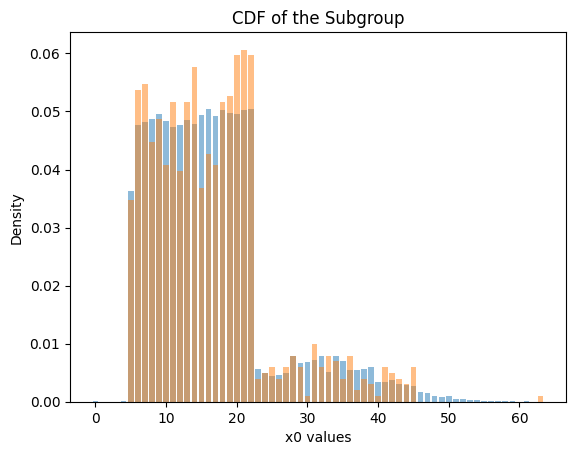

In [75]:
sub_hist = hists[best_nodes].sum(dim=0).cpu().numpy()
sub = sub_hist / sub_hist.sum()
rem_hist = walker.total_hist[0].cpu().numpy() - sub_hist
rem = rem_hist / rem_hist.sum()

sub_cdf = np.cumsum(sub)
rem_cdf = np.cumsum(rem)

# plt.plot(list(range(len(rem_cdf))), rem_cdf)
# plt.plot(list(range(len(sub_cdf))), sub_cdf)
# plt.plot(list(range(len(gt_sub_cdf))), gt_sub_cdf, alpha=0.5)
plt.bar(list(range(len(rem))), rem, alpha=0.5)
plt.bar(list(range(len(sub))), sub, alpha=0.5)
# plt.bar(list(range(len(gt_sub))), gt_sub, alpha=0.25)
plt.xlabel('x0 values')
plt.ylabel('Density')
plt.title('CDF of the Subgroup')
plt.show()